In [ ]:
from google.colab import drive
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os

drive.mount('/content/drive', force_remount=True)

content_path= "/content/drive/MyDrive/birdvsnotbird"

Mounted at /content/drive


In [ ]:
for class_name in os.listdir(content_path):
    class_folder = os.path.join(content_path, class_name)
    print("")
    if os.path.isdir(class_folder):
        print(f"\nClass: {class_name}")
        for fname in os.listdir(class_folder):
            print("  ", fname)



Class: not_bird
   img_plane3_65.jpg
   foto14704.png
   foto00204.png
   img_plane3_69.jpg
   img_plane2_12.jpg
   img_plane3_4.jpg
   foto14559.png
   img_plane3_32.jpg
   img_plane1_2.jpg
   img_plane3_49.jpg
   foto00320.png
   img_plane3_66.jpg
   img_plane1_15.jpg
   img_plane2_8.jpg
   img_plane1_1.jpg
   img_plane1_6.jpg
   img_plane1_17.jpg
   img_plane3_7.jpg
   foto14501.png
   img_plane1_27.jpg
   img_plane1_26.jpg
   img_plane1_23.jpg
   img_plane1_18.jpg
   img_plane3_46.jpg
   img_plane1_28.jpg
   img_plane2_9.jpg
   img_plane3_14.jpg
   img_plane3_39.jpg
   img_plane3_15.jpg
   img_plane1_12.jpg
   img_plane3_63.jpg
   img_plane1_10.jpg
   foto14878.png
   img_plane2_13.jpg
   img_plane3_56.jpg
   img_plane3_41.jpg
   foto14414.png
   img_plane2_4.jpg
   img_plane3_60.jpg
   img_plane2_2.jpg
   img_plane3_42.jpg
   img_plane3_44.jpg
   foto14588.png
   foto07367.png
   foto07425.png
   img_plane1_4.jpg
   foto14675.png
   img_plane2_22.jpg
   img_plane1_14.jpg
   img_

In [ ]:
import tensorflow as tf
import os

bad = []

for root, dirs, files in os.walk("/content/drive/MyDrive/birdvsnotbird"):
    for f in files:
        fp = os.path.join(root, f)
        try:
            img_bytes = tf.io.read_file(fp)
            img = tf.io.decode_image(img_bytes)
        except Exception as e:
            print("BAD FILE:", fp, "ERROR:", e)
            bad.append(fp)

print("\nTotal bad files:", len(bad))


Total bad files: 0


In [ ]:
#data processing
import os, re, shutil, random
from collections import Counter

RAW_ROOT   = '/content/drive/MyDrive/birdvsnotbird'
CLEAN_DIR  = '/content/drive/MyDrive/birdvsnotbird_clean'
SPLIT_DIR  = '/content/drive/MyDrive/birdvsnotbird_split'
MIN_PER_CLASS = 4
SPLITS = {'train':0.7, 'val':0.15, 'test':0.15}
EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

for p in [CLEAN_DIR, SPLIT_DIR]:
    shutil.rmtree(p, ignore_errors=True)
    os.makedirs(p, exist_ok=True)

all_imgs = []
for dp, dn, fn in os.walk(RAW_ROOT):
    for f in fn:
        if f.lower().endswith(EXTS):
            all_imgs.append(os.path.join(dp, f))
print('Total images found:', len(all_imgs))

def extract_label(path):
    parent = os.path.basename(os.path.dirname(path))
    return parent.strip().lower().replace(' ', '_')

labels = [extract_label(p) for p in all_imgs]
counts = Counter(labels)
keep = {lab for lab, c in counts.items() if c >= MIN_PER_CLASS}
print('Classes kept:', len(keep))
print('Kept (sample):', sorted(list(keep))[:12])

kept = 0
for p, lab in zip(all_imgs, labels):
    if lab in keep:
        out_dir = os.path.join(CLEAN_DIR, lab)
        os.makedirs(out_dir, exist_ok=True)
        shutil.copy2(p, os.path.join(out_dir, os.path.basename(p)))
        kept += 1
print('Images copied into clean class folders:', kept)

random.seed(42)
for split in SPLITS:
    os.makedirs(os.path.join(SPLIT_DIR, split), exist_ok=True)

for lab in sorted(os.listdir(CLEAN_DIR)):
    src = os.path.join(CLEAN_DIR, lab)
    if not os.path.isdir(src):
        continue
    imgs = [f for f in os.listdir(src) if f.lower().endswith(EXTS)]
    random.shuffle(imgs)
    n = len(imgs)
    n_train = max(1, int(n * SPLITS['train']))
    n_val   = max(1, int(n * SPLITS['val']))
    n_test  = max(1, n - n_train - n_val)
    splits = {
        'train': imgs[:n_train],
        'val':   imgs[n_train:n_train+n_val],
        'test':  imgs[n_train+n_val:n_train+n_val+n_test],
    }
    for sp, lst in splits.items():
        out_dir = os.path.join(SPLIT_DIR, sp, lab)
        os.makedirs(out_dir, exist_ok=True)
        for name in lst:
            shutil.copy2(os.path.join(src, name), os.path.join(out_dir, name))

for sp in ['train', 'val', 'test']:
    print(f'== {sp} ==')
    root = os.path.join(SPLIT_DIR, sp)
    for lab in sorted(os.listdir(root)):
        cnt = len(os.listdir(os.path.join(root, lab)))
        print(f'{lab:20s} {cnt}')

Total images found: 4329
Classes kept: 2
Kept (sample): ['bird', 'not_bird']
Images copied into clean class folders: 4329
== train ==
bird                 1120
not_bird             1910
== val ==
bird                 240
not_bird             409
== test ==
bird                 240
not_bird             410


In [ ]:
train_root = "/content/drive/MyDrive/birdvsnotbird_split/train"
val_root   = "/content/drive/MyDrive/birdvsnotbird_split/val"
test_root  = "/content/drive/MyDrive/birdvsnotbird_split/test"

print("TRAIN:", train_root)
print("VAL  :", val_root)
print("TEST :", test_root)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED     = 42


train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_root, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_root, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_root, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Num species:", num_classes)
print("Example species:", class_names[:10])

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

TRAIN: /content/drive/MyDrive/birdvsnotbird_split/train
VAL  : /content/drive/MyDrive/birdvsnotbird_split/val
TEST : /content/drive/MyDrive/birdvsnotbird_split/test
Found 3030 files belonging to 2 classes.
Found 649 files belonging to 2 classes.
Found 650 files belonging to 2 classes.
Num species: 2
Example species: ['bird', 'not_bird']


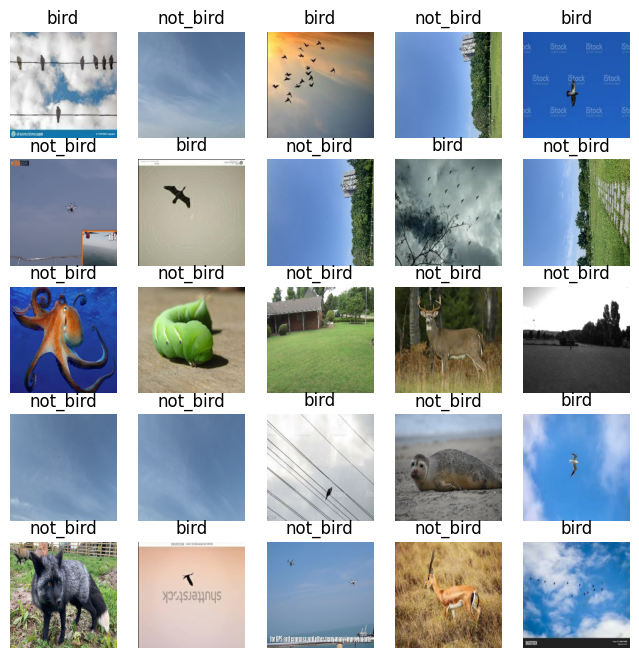

In [ ]:
import matplotlib.pyplot as plt
images, labels = next(iter(train_ds))
plt.figure(figsize=(8,8))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i].numpy()])
    plt.axis("off")
plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

# build the CNN (what learns to recognize patterns)
def tiny_cnn(num_classes):
    inputs = keras.Input(shape=IMG_SIZE + (3,))     # 224x224 RGB
    x = layers.Rescaling(1./255)(inputs)            # scale pixels to [0,1]
    x = layers.Conv2D(32, 3, activation="relu")(x)  # edges/colors
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu")(x)  # bigger shapes
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation="relu")(x) # detailed features
    x = layers.GlobalAveragePooling2D()(x)          # compress features
    x = layers.Dropout(0.3)(x)                      # reduce overfitting
    outputs = layers.Dense(num_classes, activation="softmax")(x)  # class probs
    return keras.Model(inputs, outputs)

# build the model and prepare it for training
model = tiny_cnn(num_classes)


model.compile(
    optimizer=keras.optimizers.Adam(5e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

# train the model (learn from train_ds; validate on unseen val_ds each epoch)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=4,
            restore_best_weights=True
        )
    ]
)

Epoch 1/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.6450 - loss: 0.6515 - val_accuracy: 0.7396 - val_loss: 0.5601
Epoch 2/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7470 - loss: 0.5392 - val_accuracy: 0.7581 - val_loss: 0.4676
Epoch 3/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8057 - loss: 0.4608 - val_accuracy: 0.7935 - val_loss: 0.4172
Epoch 4/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7827 - loss: 0.4829 - val_accuracy: 0.7858 - val_loss: 0.4191
Epoch 5/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7775 - loss: 0.4746 - val_accuracy: 0.8166 - val_loss: 0.4179
Epoch 6/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7921 - loss: 0.4487 - val_accuracy: 0.7904 - val_loss: 0.4003
Epoch 7/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8074 - loss: 0.4347 - val_accuracy: 0.8151 - val_loss: 0.4225
Epoch 8/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8133 - loss: 0.4234 - val_accuracy: 0.8505 - 

In [ ]:
# Save model, plots, and evaluation results
import os, json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score

SAVE_DIR = "/content/drive/MyDrive/BirdVSNotBirdModel/results/baselineCNNBirdVSNotBird"
os.makedirs(SAVE_DIR, exist_ok=True)

model.save(f"{SAVE_DIR}/baseline_cnn_bird_detector.keras")
with open(f"{SAVE_DIR}/class_names.json", "w") as f:
    json.dump(class_names, f)
with open(f"{SAVE_DIR}/history.json", "w") as f:
    json.dump(history.history, f)

In [ ]:

# Plot accuracy and loss
plt.figure()
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Baseline CNN — Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.savefig(f"{SAVE_DIR}/baseline_accuracy.png", dpi=160)
plt.close()

plt.figure()
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Baseline CNN — Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.savefig(f"{SAVE_DIR}/baseline_loss.png", dpi=160)
plt.close()

# Evaluate and report
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred = np.concatenate([np.argmax(model.predict(x, verbose=0), axis=1) for x, _ in test_ds])

report = classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average="macro")

with open(f"{SAVE_DIR}/baseline_report.txt", "w") as f:
    f.write(report + f"\nMacro-F1: {macro_f1:.3f}\n")

print(report)
print("Macro-F1:", macro_f1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation='nearest')
plt.title('Baseline CNN — Confusion Matrix')
plt.colorbar()
plt.xticks([]); plt.yticks([])  # too many classes
plt.tight_layout()
plt.xlabel('Predicted'); plt.ylabel('True')
plt.savefig(f"{SAVE_DIR}/baseline_confusion_matrix.png", dpi=180, bbox_inches='tight')
plt.close()

              precision    recall  f1-score   support

        bird      0.796     0.863     0.828       240
    not_bird      0.915     0.871     0.892       410

    accuracy                          0.868       650
   macro avg      0.856     0.867     0.860       650
weighted avg      0.871     0.868     0.869       650

Macro-F1: 0.86025


Continue training the model with new processed data

In [ ]:
from tensorflow.keras.models import load_model
SAVE_DIR = "/content/drive/MyDrive/BirdVSNotBirdModel/results/baselineCNNBirdVSNotBird"
loaded_model = load_model(f"{SAVE_DIR}/baseline_cnn_bird_detector.keras")